# Vehicle Price Prediction

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Modeling & Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# Visualization aesthetics
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette('deep')
import warnings
warnings.filterwarnings('ignore')

print("All libraries successfully imported!")

All libraries successfully imported!


## 2. Load and Inspect Dataset

In [2]:
# Load vehicle dataset
df = pd.read_csv('car_price_data.csv')
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns\n")

# Display first 5 records
df.head()

Dataset Dimensions: 1200 rows, 11 columns



,Year,Present_Price,Driven_Kms,Fuel_Type,Transmission,Owner_Type,Segment,Engine_Size,Horsepower,Fuel_Efficiency_MPG,Selling_Price
0,2014,19665.10,127842,CNG,Automatic,Second,Economy,1.1,104,28.4,3016.97
1,2011,19164.45,197499,Diesel,Automatic,First,Economy,1.1,79,32.0,2760.66
2,2020,14567.98,52688,Petrol,Manual,First,Economy,1.5,83,27.4,7568.33
3,2022,14187.80,42486,Petrol,Automatic,Third,Economy,1.3,93,26.5,8852.59
4,2018,12394.36,55775,Petrol,Manual,First,Economy,1.4,67,29.1,3452.82


In [3]:
# Dataset schema and missing values
print("=== Dataset Information ===")
df.info()

print("\n=== Missing Values Check ===")
print(df.isnull().sum())

# Numerical statistics
print("\n=== Numerical Statistics Summary ===")
df.describe().round(2)

=== Dataset Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year                 1200 non-null   int64  
 1   Present_Price        1200 non-null   float64
 2   Driven_Kms           1200 non-null   int64  
 3   Fuel_Type            1200 non-null   object 
 4   Transmission         1200 non-null   object 
 5   Owner_Type           1200 non-null   object 
 6   Segment              1200 non-null   object 
 7   Engine_Size          1200 non-null   float64
 8   Horsepower           1200 non-null   int64  
 9   Fuel_Efficiency_MPG  1200 non-null   float64
 10  Selling_Price        1200 non-null   float64
dtypes: float64(4), int64(3), object(4)
memory usage: 103.3+ KB

=== Missing Values Check ===
Year                   0
Present_Price          0
Driven_Kms             0
Fuel_Type              0
Transmission         

,Year,Present_Price,Driven_Kms,Engine_Size,Horsepower,Fuel_Efficiency_MPG,Selling_Price
count,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00
mean,2015.47,32278.12,109864.01,1.88,150.67,26.49,9955.89
std,4.71,19291.27,62480.75,0.66,74.16,3.44,11102.84
min,2008.00,12001.93,3992.00,1.00,65.00,14.70,1679.85
25%,2011.00,18302.44,56634.25,1.40,96.75,24.40,3538.36
50%,2015.00,28009.60,101656.50,1.70,133.00,26.90,5788.58
75%,2020.00,38550.96,153590.25,2.30,183.00,29.00,12737.33
max,2023.00,109956.40,250000.00,4.00,418.00,32.00,95260.42


## 3. Exploratory Data Analysis (EDA)

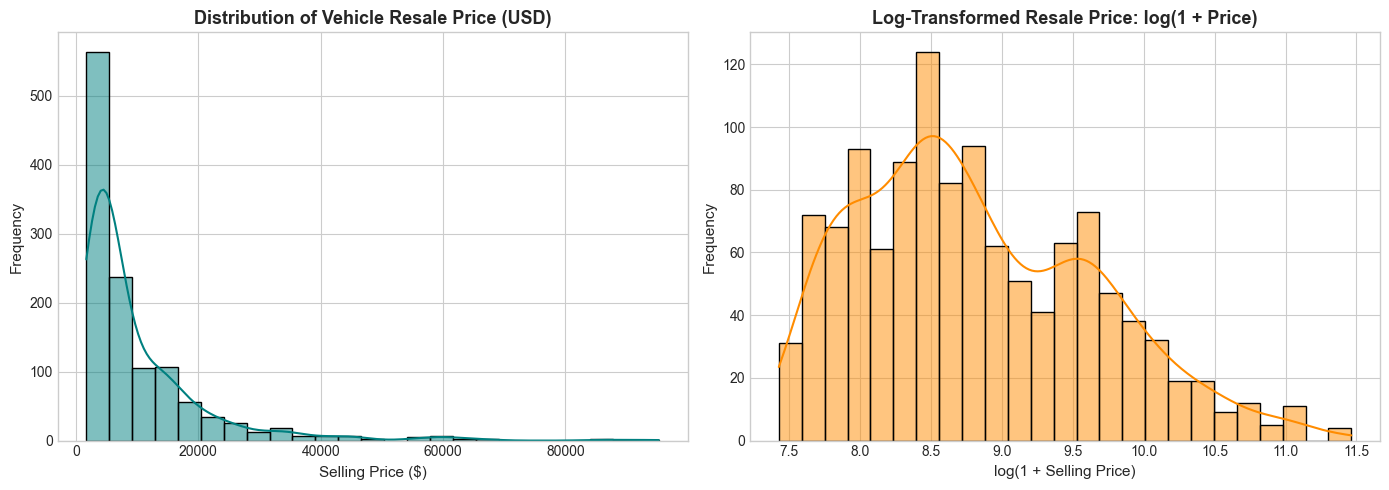

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw Selling Price Distribution
sns.histplot(df['Selling_Price'], kde=True, color='teal', bins=25, ax=axes[0])
axes[0].set_title('Distribution of Vehicle Resale Price (USD)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Selling Price ($)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)

# Log-Transformed Selling Price Distribution
sns.histplot(np.log1p(df['Selling_Price']), kde=True, color='darkorange', bins=25, ax=axes[1])
axes[1].set_title('Log-Transformed Resale Price: log(1 + Price)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(1 + Selling Price)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)

plt.tight_layout()
plt.show()

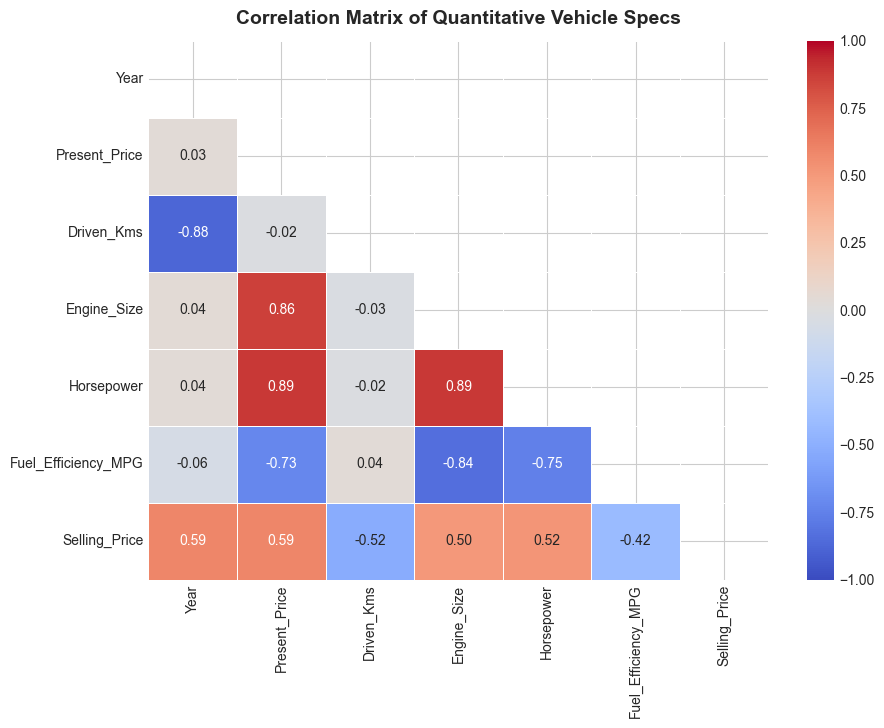

In [5]:
plt.figure(figsize=(10, 7))
num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix of Quantitative Vehicle Specs', fontsize=14, fontweight='bold', pad=12)
plt.show()

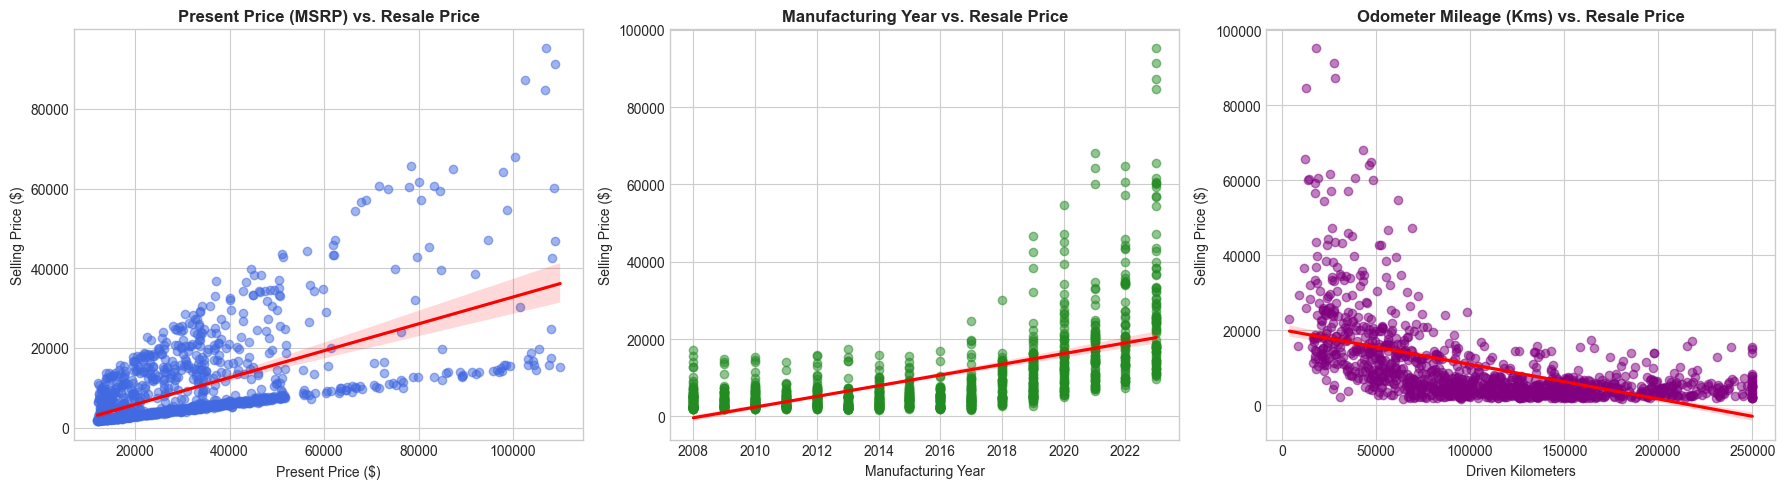

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Present Price vs Selling Price
sns.regplot(data=df, x='Present_Price', y='Selling_Price', ax=axes[0],
            scatter_kws={'alpha':0.5, 'color':'royalblue'}, line_kws={'color':'red'})
axes[0].set_title('Present Price (MSRP) vs. Resale Price', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Present Price ($)')
axes[0].set_ylabel('Selling Price ($)')

# Year vs Selling Price (Age Depreciation)
sns.regplot(data=df, x='Year', y='Selling_Price', ax=axes[1],
            scatter_kws={'alpha':0.5, 'color':'forestgreen'}, line_kws={'color':'red'})
axes[1].set_title('Manufacturing Year vs. Resale Price', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Manufacturing Year')
axes[1].set_ylabel('Selling Price ($)')

# Driven Kms vs Selling Price
sns.regplot(data=df, x='Driven_Kms', y='Selling_Price', ax=axes[2],
            scatter_kws={'alpha':0.5, 'color':'purple'}, line_kws={'color':'red'})
axes[2].set_title('Odometer Mileage (Kms) vs. Resale Price', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Driven Kilometers')
axes[2].set_ylabel('Selling Price ($)')

plt.tight_layout()
plt.show()

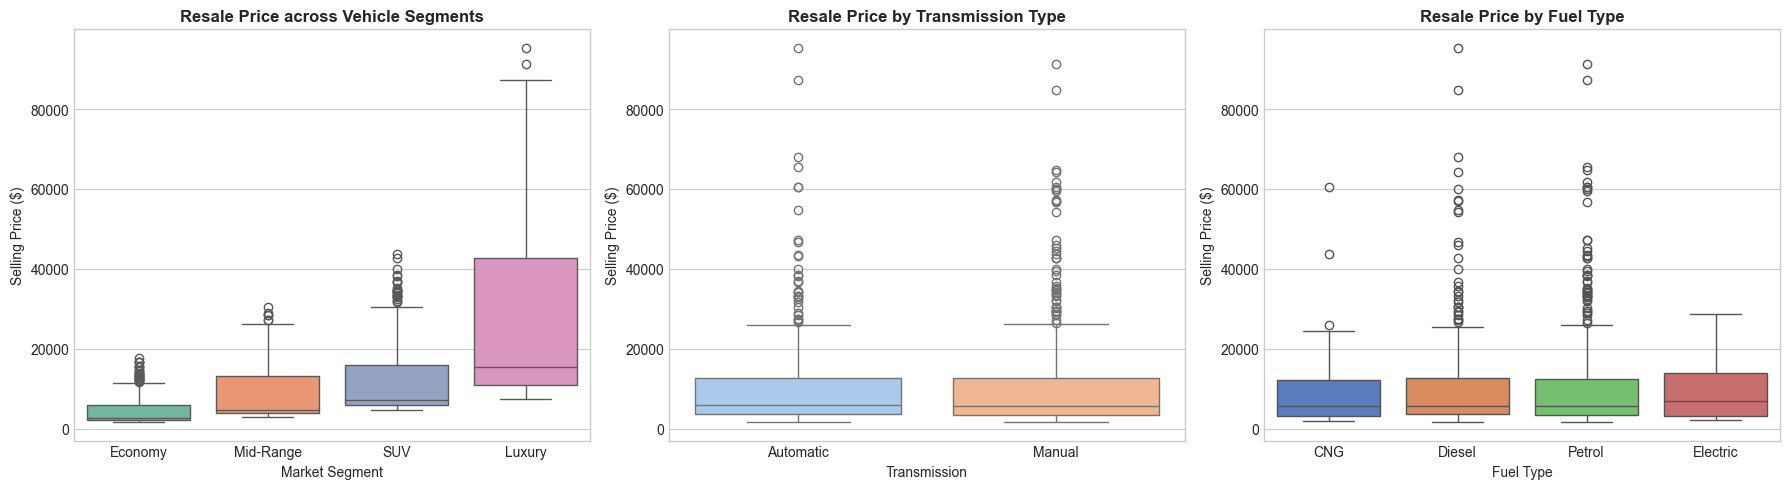

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Segment vs Selling Price
sns.boxplot(data=df, x='Segment', y='Selling_Price', palette='Set2', ax=axes[0])
axes[0].set_title('Resale Price across Vehicle Segments', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Market Segment')
axes[0].set_ylabel('Selling Price ($)')

# Transmission vs Selling Price
sns.boxplot(data=df, x='Transmission', y='Selling_Price', palette='pastel', ax=axes[1])
axes[1].set_title('Resale Price by Transmission Type', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Transmission')
axes[1].set_ylabel('Selling Price ($)')

# Fuel Type vs Selling Price
sns.boxplot(data=df, x='Fuel_Type', y='Selling_Price', palette='muted', ax=axes[2])
axes[2].set_title('Resale Price by Fuel Type', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Fuel Type')
axes[2].set_ylabel('Selling Price ($)')

plt.tight_layout()
plt.show()

## 4. Feature Engineering and Preprocessing

In [8]:
# 1. Feature Engineering
CURRENT_YEAR = 2024
df_eng = df.copy()
df_eng['Vehicle_Age'] = CURRENT_YEAR - df_eng['Year']
df_eng['Kms_Per_Year'] = (df_eng['Driven_Kms'] / df_eng['Vehicle_Age']).round(1)

# Drop original Year column since Vehicle_Age encapsulates it
df_eng = df_eng.drop(columns=['Year'])

# 2. Ordinal Encoding for Owner_Type
owner_map = {'First': 0, 'Second': 1, 'Third': 2}
df_eng['Owner_Type'] = df_eng['Owner_Type'].map(owner_map)

# 3. One-Hot Encoding for remaining nominal categories
df_eng = pd.get_dummies(df_eng, columns=['Fuel_Type', 'Transmission', 'Segment'], drop_first=True, dtype=int)

print(f"Engineered Dataset Shape: {df_eng.shape}")
df_eng.head()

Engineered Dataset Shape: (1200, 16)


,Present_Price,Driven_Kms,Owner_Type,Engine_Size,Horsepower,Fuel_Efficiency_MPG,Selling_Price,Vehicle_Age,Kms_Per_Year,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_Petrol,Transmission_Manual,Segment_Luxury,Segment_Mid-Range,Segment_SUV
0,19665.10,127842,1,1.1,104,28.4,3016.97,10,12784.2,0,0,0,0,0,0,0
1,19164.45,197499,0,1.1,79,32.0,2760.66,13,15192.2,1,0,0,0,0,0,0
2,14567.98,52688,0,1.5,83,27.4,7568.33,4,13172.0,0,0,1,1,0,0,0
3,14187.80,42486,2,1.3,93,26.5,8852.59,2,21243.0,0,0,1,0,0,0,0
4,12394.36,55775,0,1.4,67,29.1,3452.82,6,9295.8,0,0,1,1,0,0,0


In [9]:
# Separate features and target
X = df_eng.drop(columns=['Selling_Price'])
y = df_eng['Selling_Price']

# 80-20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Standardize numerical continuous features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")
print("Features count:", X.shape[1])

Training set: 960 samples
Testing set:  240 samples
Features count: 15


## 5. Model Training (Linear, Ridge, Lasso, Decision Tree, Random Forest, Gradient Boosting)

In [10]:
# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression (L2)': Ridge(alpha=10.0),
    'Lasso Regression (L1)': Lasso(alpha=5.0),
    'Decision Tree': DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=120, learning_rate=0.08, max_depth=5, random_state=42)
}

predictions = {}

for name, model in models.items():
    if 'Forest' in name or 'Tree' in name or 'Boosting' in name:
        # Tree-based algorithms operate naturally on raw unscaled features
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
    else:
        # Linear models benefit from standardized feature scales
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
    predictions[name] = pred
    print(f"Model trained: {name:25s}")

Model trained: Linear Regression        
Model trained: Ridge Regression (L2)    
Model trained: Lasso Regression (L1)    
Model trained: Decision Tree            


Model trained: Random Forest            


Model trained: Gradient Boosting        


## 6. Model Evaluation and Performance Comparison

In [11]:
results_list = []

for name, model in models.items():
    pred = predictions[name]
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    mape = mean_absolute_percentage_error(y_test, pred) * 100
    
    # 5-Fold Cross Validation
    X_cv = X_train if ('Forest' in name or 'Tree' in name or 'Boosting' in name) else X_train_scaled
    cv_scores = cross_val_score(model, X_cv, y_train, cv=5, scoring='r2')
    
    results_list.append({
        'Model': name,
        'MAE ($)': round(mae, 2),
        'RMSE ($)': round(rmse, 2),
        'R² Score': round(r2, 4),
        'MAPE (%)': round(mape, 2),
        'CV 5-Fold R²': round(cv_scores.mean(), 4)
    })

eval_df = pd.DataFrame(results_list).sort_values(by='R² Score', ascending=False)
print("=== Vehicle Price Prediction Model Benchmark ===")
eval_df

=== Vehicle Price Prediction Model Benchmark ===


,Model,MAE ($),RMSE ($),R² Score,MAPE (%),CV 5-Fold R²
5,Gradient Boosting,731.32,1647.58,0.9760,6.20,0.9754
4,Random Forest,843.30,1717.65,0.9739,7.50,0.9609
3,Decision Tree,1275.09,2927.03,0.9242,10.04,0.9135
1,Ridge Regression (L2),3962.50,5998.06,0.6817,61.54,0.6929
2,Lasso Regression (L1),3982.07,6032.14,0.6781,61.04,0.6915
0,Linear Regression,3985.96,6044.81,0.6767,60.72,0.6903


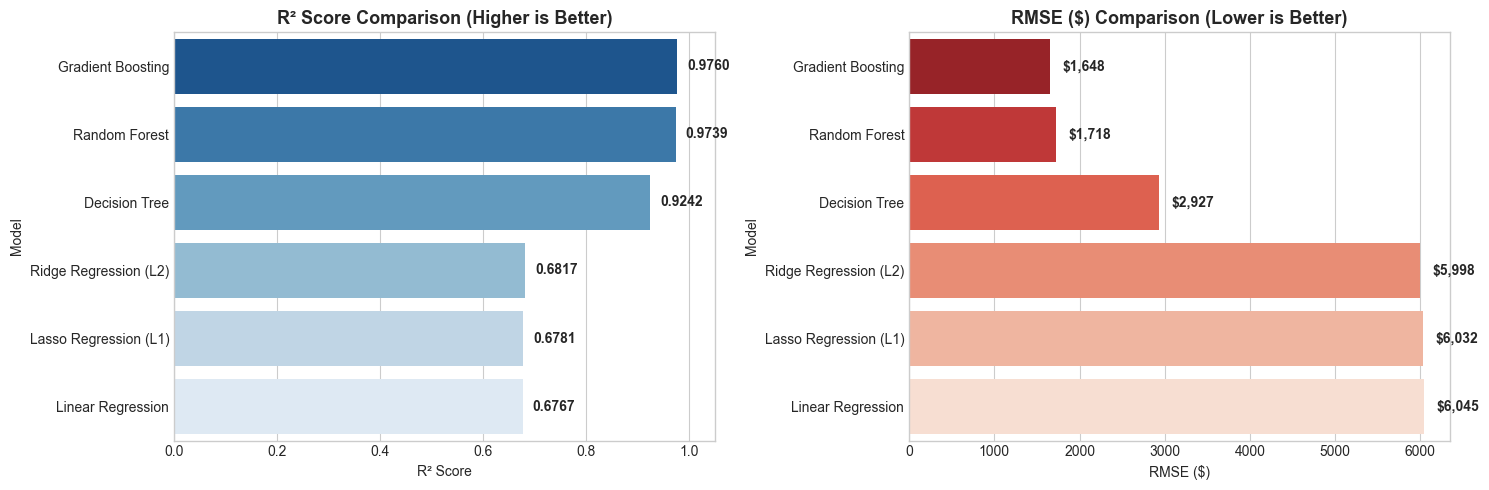

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot R2 Scores
sns.barplot(data=eval_df, x='R² Score', y='Model', palette='Blues_r', ax=axes[0])
axes[0].set_title('R² Score Comparison (Higher is Better)', fontsize=13, fontweight='bold')
axes[0].set_xlim(0, 1.05)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_width():.4f}", 
                     (p.get_width() + 0.02, p.get_y() + p.get_height() / 2),
                     va='center', fontsize=10, fontweight='bold')

# Plot RMSE
sns.barplot(data=eval_df, x='RMSE ($)', y='Model', palette='Reds_r', ax=axes[1])
axes[1].set_title('RMSE ($) Comparison (Lower is Better)', fontsize=13, fontweight='bold')
for p in axes[1].patches:
    axes[1].annotate(f"${p.get_width():,.0f}", 
                     (p.get_width() + 150, p.get_y() + p.get_height() / 2),
                     va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Model Diagnostics and Feature Importance

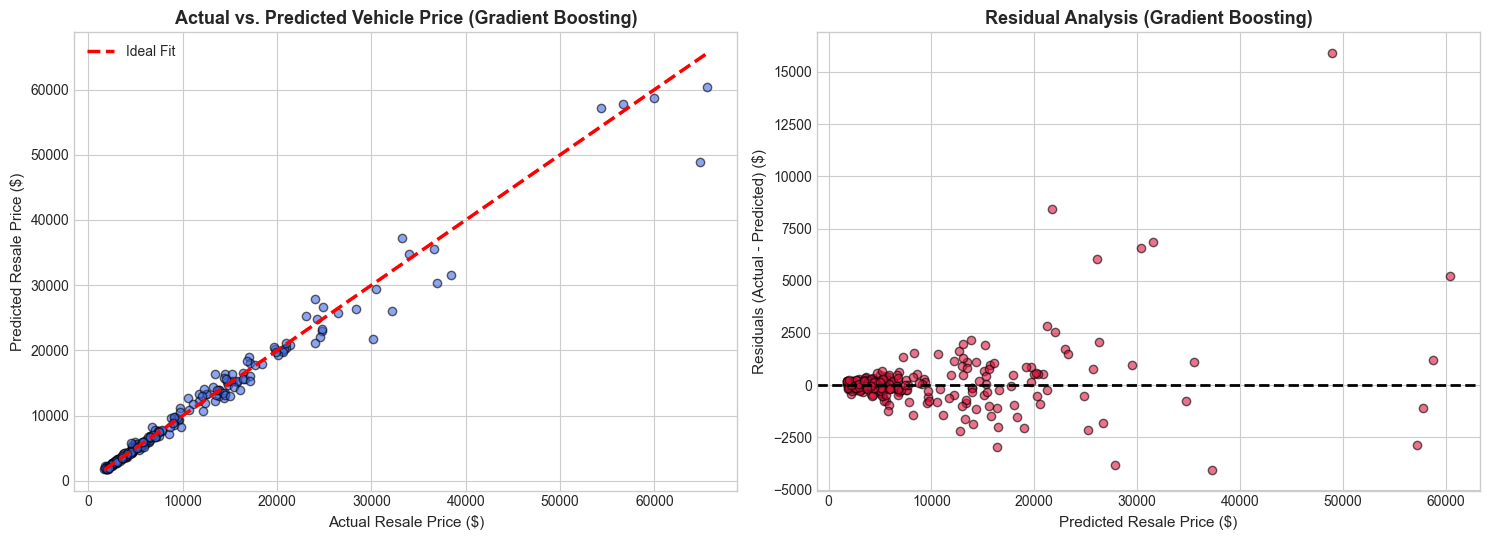

In [13]:
best_model_name = 'Gradient Boosting'
best_preds = predictions[best_model_name]
residuals = y_test - best_preds

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Actual vs Predicted
axes[0].scatter(y_test, best_preds, color='royalblue', alpha=0.6, edgecolors='k')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2.5, label='Ideal Fit')
axes[0].set_title(f'Actual vs. Predicted Vehicle Price ({best_model_name})', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Actual Resale Price ($)', fontsize=11)
axes[0].set_ylabel('Predicted Resale Price ($)', fontsize=11)
axes[0].legend()

# Residual Plot
axes[1].scatter(best_preds, residuals, color='crimson', alpha=0.6, edgecolors='k')
axes[1].axhline(y=0, color='black', linestyle='--', lw=2)
axes[1].set_title(f'Residual Analysis ({best_model_name})', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Resale Price ($)', fontsize=11)
axes[1].set_ylabel('Residuals (Actual - Predicted) ($)', fontsize=11)

plt.tight_layout()
plt.show()

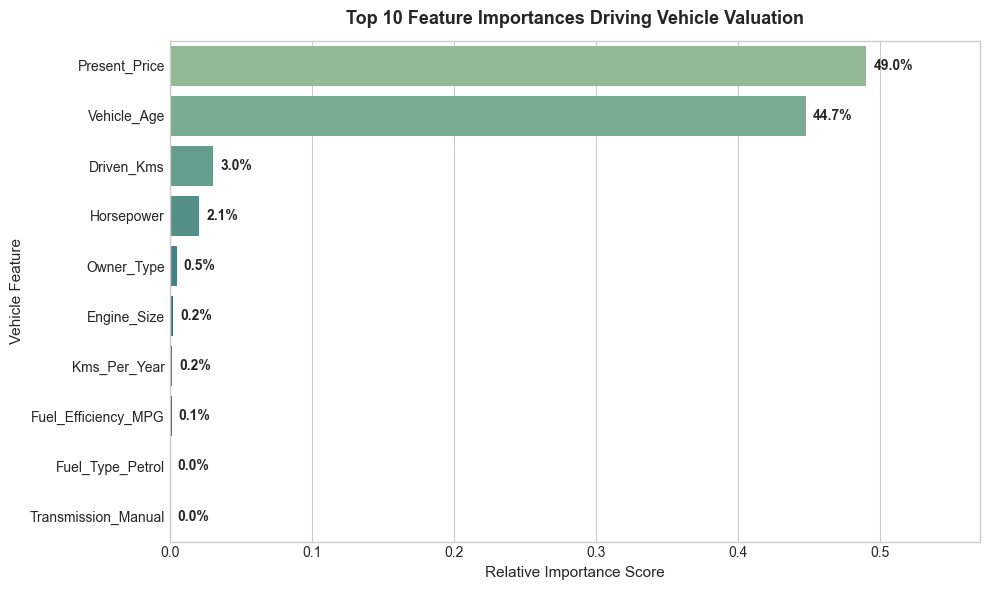

In [14]:
# Feature Importance from Gradient Boosting Model
gb_model = models['Gradient Boosting']
feat_importance = pd.Series(gb_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_importance.values[:10], y=feat_importance.index[:10], palette='crest')
plt.title('Top 10 Feature Importances Driving Vehicle Valuation', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Relative Importance Score', fontsize=11)
plt.ylabel('Vehicle Feature', fontsize=11)
for idx, val in enumerate(feat_importance.values[:10]):
    plt.text(val + 0.005, idx, f"{val*100:.1f}%", va='center', fontsize=10, fontweight='bold')
plt.xlim(0, max(feat_importance.values) + 0.08)
plt.tight_layout()
plt.show()

## 8. Vehicle Valuation Predictor

In [15]:
def estimate_vehicle_price(present_price, year, driven_kms, fuel_type, transmission, 
                           owner_type, segment, engine_size, horsepower, fuel_efficiency):
    """
    Estimates market resale price using the trained Gradient Boosting model.
    """
    age = CURRENT_YEAR - year
    kms_per_year = driven_kms / max(age, 1)
    
    car_dict = {
        'Present_Price': present_price,
        'Driven_Kms': driven_kms,
        'Owner_Type': owner_map.get(owner_type, 0),
        'Engine_Size': engine_size,
        'Horsepower': horsepower,
        'Fuel_Efficiency_MPG': fuel_efficiency,
        'Vehicle_Age': age,
        'Kms_Per_Year': kms_per_year,
        'Fuel_Type_Diesel': 1 if fuel_type.lower() == 'diesel' else 0,
        'Fuel_Type_Electric': 1 if fuel_type.lower() == 'electric' else 0,
        'Fuel_Type_Petrol': 1 if fuel_type.lower() == 'petrol' else 0,
        'Transmission_Manual': 1 if transmission.lower() == 'manual' else 0,
        'Segment_Luxury': 1 if segment.lower() == 'luxury' else 0,
        'Segment_Mid-Range': 1 if segment.lower() == 'mid-range' else 0,
        'Segment_SUV': 1 if segment.lower() == 'suv' else 0
    }
    
    input_df = pd.DataFrame([car_dict])[X.columns]
    pred_price = gb_model.predict(input_df)[0]
    return pred_price

# Test Case 1: 2021 Toyota Mid-Range Sedan
test_car_1 = {
    'present_price': 28000,
    'year': 2021,
    'driven_kms': 32000,
    'fuel_type': 'Petrol',
    'transmission': 'Automatic',
    'owner_type': 'First',
    'segment': 'Mid-Range',
    'engine_size': 1.8,
    'horsepower': 140,
    'fuel_efficiency': 27.5
}

# Test Case 2: 2013 Luxury SUV
test_car_2 = {
    'present_price': 65000,
    'year': 2013,
    'driven_kms': 120000,
    'fuel_type': 'Diesel',
    'transmission': 'Automatic',
    'owner_type': 'Second',
    'segment': 'Luxury',
    'engine_size': 3.0,
    'horsepower': 260,
    'fuel_efficiency': 21.0
}

val_1 = estimate_vehicle_price(**test_car_1)
val_2 = estimate_vehicle_price(**test_car_2)

print("=== Sample Vehicle Price Estimations ===")
print(f"Vehicle 1: 2021 Mid-Range Sedan (Original MSRP: ${test_car_1['present_price']:,})")
print(f"  Estimated Resale Value: ${val_1:,.2f} (Retains {val_1/test_car_1['present_price']*100:.1f}% MSRP)\n")

print(f"Vehicle 2: 2013 Luxury SUV (Original MSRP: ${test_car_2['present_price']:,}, 120,000 kms)")
print(f"  Estimated Resale Value: ${val_2:,.2f} (Retains {val_2/test_car_2['present_price']*100:.1f}% MSRP)")

=== Sample Vehicle Price Estimations ===
Vehicle 1: 2021 Mid-Range Sedan (Original MSRP: $28,000)
  Estimated Resale Value: $17,771.71 (Retains 63.5% MSRP)

Vehicle 2: 2013 Luxury SUV (Original MSRP: $65,000, 120,000 kms)
  Estimated Resale Value: $9,285.25 (Retains 14.3% MSRP)


## 9. Conclusion